# Phase 2 — Conformal Coverage Under Post-Training Quantisation
**Project:** Edge Perception — Conformal Prediction Extension  
**Author:** Faizan Shafi Seroo  
**Date:** June 2026

---

## What This Notebook Does
This notebook extends Phase 1 (confidence calibration under quantisation) by applying **split conformal prediction** to measure whether post-training quantisation preserves formal statistical coverage guarantees.

**Structure:**
- Part 1 — Setup: paths, imports, model loading
- Part 2 — Dataset: COCO128 calibration split + COCO val2017 test download
- Part 3 — Conformal Calibration: compute q_hat per precision level
- Part 4 — Clean Test Evaluation: coverage on undegraded val2017 images
- Part 5 — Degradation Pipeline: apply blur, JPEG, noise to val2017 test images
- Part 6 — Degraded Test Evaluation: coverage across all 24 conditions
- Part 7 — Results & Statistical Analysis

---
## Part 1 — Setup

In [1]:
# Core imports
import sys
import os
import json
import math
import random
import shutil
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

print("All imports successful.")

All imports successful.


In [2]:
# ── Project paths ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"C:\Users\faiza\Documents\edge-perception-project")
BASE_DIR     = PROJECT_ROOT / "conformal_yolov8n"
SRC_DIR      = BASE_DIR / "src"
MODELS_DIR   = BASE_DIR / "models" / "exports"
DATA_DIR     = BASE_DIR / "data"
RESULTS_DIR  = BASE_DIR / "results"
TABLES_DIR   = RESULTS_DIR / "tables"

# ── Dataset paths ──────────────────────────────────────────────────────────────
COCO128_IMG_DIR = Path(r"C:\Users\faiza\datasets\coco128\images\train2017")
COCO128_LBL_DIR = Path(r"C:\Users\faiza\datasets\coco128\labels\train2017")

# COCO val2017 will be downloaded here
COCO_VAL_DIR     = Path(r"C:\Users\faiza\datasets\coco_val2017")
COCO_VAL_IMG_DIR = COCO_VAL_DIR / "images"
COCO_VAL_LBL_DIR = COCO_VAL_DIR / "labels"

# ── Conformal settings ─────────────────────────────────────────────────────────
ALPHA         = 0.10   # error rate → targeting 90% coverage
IOU_THRESHOLD = 0.50   # minimum IoU to count a detection as a true positive
RANDOM_STATE  = 42     # for reproducible splits and sampling
N_VAL_IMAGES  = 200    # number of COCO val2017 images to use as test set

# ── Create output folders if they don't exist ──────────────────────────────────
for folder in [DATA_DIR, RESULTS_DIR, TABLES_DIR, COCO_VAL_DIR,
               COCO_VAL_IMG_DIR, COCO_VAL_LBL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Verify critical paths exist
assert COCO128_IMG_DIR.exists(), f"COCO128 images not found at {COCO128_IMG_DIR}"
assert COCO128_LBL_DIR.exists(), f"COCO128 labels not found at {COCO128_LBL_DIR}"
assert MODELS_DIR.exists(),      f"Models folder not found at {MODELS_DIR}"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("MODELS_DIR   :", MODELS_DIR)
print("COCO128 imgs :", COCO128_IMG_DIR)
print("COCO val2017 :", COCO_VAL_DIR)
print("All paths OK.")

PROJECT_ROOT : C:\Users\faiza\Documents\edge-perception-project
MODELS_DIR   : C:\Users\faiza\Documents\edge-perception-project\conformal_yolov8n\models\exports
COCO128 imgs : C:\Users\faiza\datasets\coco128\images\train2017
COCO val2017 : C:\Users\faiza\datasets\coco_val2017
All paths OK.


In [3]:
# Load conformal_utils.py from the src folder
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import importlib
import conformal_utils
importlib.reload(conformal_utils)   # ensures latest version is loaded

from conformal_utils import (
    load_yolo_labels,
    compute_iou,
    compute_nonconformity,
    conformal_quantile,
    conformal_accept,
    collect_calibration_data,
    evaluate_on_test,
)

print("conformal_utils loaded successfully.")

conformal_utils loaded successfully.


In [4]:
# Load all three precision models

# FP32 — PyTorch baseline (assumes yolov8n.pt is on your PATH or in cwd)
fp32_model = YOLO("yolov8n.pt")
print("FP32 model loaded.")

# FP16 — OpenVINO half-precision
fp16_model = YOLO(str(MODELS_DIR / "yolov8n_openvino_model"))
print("FP16 model loaded.")

# INT8 — OpenVINO 8-bit integer
int8_model = YOLO(str(MODELS_DIR / "yolov8n_int8_openvino_model"))
print("INT8 model loaded.")

MODELS = {"FP32": fp32_model, "FP16": fp16_model, "INT8": int8_model}
print("\nAll 3 models ready.")

FP32 model loaded.
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
FP16 model loaded.
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
INT8 model loaded.

All 3 models ready.


---
## Part 2 — Dataset Preparation

### Strategy
| Role | Dataset | Size |
|---|---|---|
| Conformal calibration | COCO128 train2017 (70%) | ~88 images |
| Clean test set | COCO val2017 (sampled) | 200 images |
| Degraded test sets | Same 200 val2017 images, degraded | 200 × 7 conditions |

**Why separate datasets?**  
The INT8 model was calibrated by OpenVINO's NNCF using COCO128 images during export. Using those same images as the conformal test set would introduce data leakage. COCO val2017 images were never seen during INT8 export, making them a clean, unbiased test set.

In [5]:
# ── COCO128: calibration / held-out split ──────────────────────────────────────
# Collect all image paths that have a matching label file
all_coco128 = sorted(
    p for p in COCO128_IMG_DIR.glob("*.jpg")
    if (COCO128_LBL_DIR / f"{p.stem}.txt").exists()
)

print(f"Total COCO128 image/label pairs found: {len(all_coco128)}")

# 70% calibration, 30% held-out (held-out not used; val2017 is test)
calib_paths, _ = train_test_split(
    all_coco128,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

print(f"Calibration images (70%): {len(calib_paths)}")
print(f"Example: {calib_paths[0].name}")

Total COCO128 image/label pairs found: 126
Calibration images (70%): 88
Example: 000000000257.jpg


In [7]:
# ── Download COCO val2017 images and annotations ───────────────────────────────
# This cell downloads ~1GB of val2017 images and the annotations JSON.
# It only runs if the images are not already present.
# After download, it converts COCO JSON annotations to YOLO .txt format.

VAL_ZIP_PATH  = COCO_VAL_DIR / "val2017.zip"
ANN_ZIP_PATH  = COCO_VAL_DIR / "annotations.zip"
ANN_JSON_PATH = COCO_VAL_DIR / "annotations" / "instances_val2017.json"

# Step 1: Images
if not COCO_VAL_IMG_DIR.exists() or len(list(COCO_VAL_IMG_DIR.glob("*.jpg"))) < 100:
    print("Downloading COCO val2017 images (~1GB). This may take a few minutes...")
    urllib.request.urlretrieve(
        "http://images.cocodataset.org/zips/val2017.zip",
        VAL_ZIP_PATH
    )
    print("Download complete. Extracting...")
    with zipfile.ZipFile(VAL_ZIP_PATH, "r") as z:
        z.extractall(COCO_VAL_DIR)
    extracted = COCO_VAL_DIR / "val2017"
if extracted.exists():
    # If images folder already exists (created by mkdir earlier), remove it first
    if COCO_VAL_IMG_DIR.exists():
        COCO_VAL_IMG_DIR.rmdir()   # only works if empty
    extracted.rename(COCO_VAL_IMG_DIR)
    VAL_ZIP_PATH.unlink(missing_ok=True)
    print(f"Images ready: {len(list(COCO_VAL_IMG_DIR.glob('*.jpg')))} images")
else:
    print(f"COCO val2017 images already present: {len(list(COCO_VAL_IMG_DIR.glob('*.jpg')))} images")

# Step 2: Annotations
if not ANN_JSON_PATH.exists():
    print("Downloading COCO annotations (~241MB)...")
    urllib.request.urlretrieve(
        "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
        ANN_ZIP_PATH
    )
    print("Extracting annotations...")
    with zipfile.ZipFile(ANN_ZIP_PATH, "r") as z:
        z.extractall(COCO_VAL_DIR)
    ANN_ZIP_PATH.unlink(missing_ok=True)
    print("Annotations ready.")
else:
    print("Annotations already present.")

Download complete. Extracting...
Images ready: 5000 images
Extracting annotations...
Annotations ready.


In [8]:
# ── Convert COCO JSON annotations → YOLO .txt format ──────────────────────────
# YOLO format per line: class_id x_center y_center width height  (all normalised)

already_converted = len(list(COCO_VAL_LBL_DIR.glob("*.txt"))) > 100

if not already_converted:
    print("Converting COCO JSON annotations to YOLO format...")

    with open(ANN_JSON_PATH, "r") as f:
        coco_data = json.load(f)

    # image_id → {filename, width, height}
    image_info = {
        img["id"]: {"file": img["file_name"], "w": img["width"], "h": img["height"]}
        for img in coco_data["images"]
    }

    # category_id → YOLO class index (0-based, sorted by id)
    sorted_cats     = sorted(coco_data["categories"], key=lambda c: c["id"])
    cat_id_to_yolo  = {cat["id"]: i for i, cat in enumerate(sorted_cats)}

    # group annotations by image_id
    from collections import defaultdict
    ann_by_image = defaultdict(list)
    for ann in coco_data["annotations"]:
        if ann.get("iscrowd", 0) == 0:
            ann_by_image[ann["image_id"]].append(ann)

    COCO_VAL_LBL_DIR.mkdir(parents=True, exist_ok=True)

    written = 0
    for img_id, info in image_info.items():
        stem       = Path(info["file"]).stem
        label_path = COCO_VAL_LBL_DIR / f"{stem}.txt"
        anns       = ann_by_image.get(img_id, [])

        lines = []
        for ann in anns:
            x, y, w, h = ann["bbox"]  # COCO: top-left x,y,width,height
            x_c = (x + w / 2) / info["w"]
            y_c = (y + h / 2) / info["h"]
            w_n = w / info["w"]
            h_n = h / info["h"]
            cls = cat_id_to_yolo[ann["category_id"]]
            lines.append(f"{cls} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}")

        with open(label_path, "w") as lf:
            lf.write("\n".join(lines))
        written += 1

    print(f"Conversion complete. Labels written: {written}")
else:
    print(f"Labels already converted: {len(list(COCO_VAL_LBL_DIR.glob('*.txt')))} files")

Converting COCO JSON annotations to YOLO format...
Conversion complete. Labels written: 5000


In [6]:
# ── Sample N_VAL_IMAGES from val2017 as the fixed test set ─────────────────────
# Only images that have a non-empty label file are included.

all_val_imgs = sorted(COCO_VAL_IMG_DIR.glob("*.jpg"))

annotated_val = [
    p for p in all_val_imgs
    if (COCO_VAL_LBL_DIR / f"{p.stem}.txt").exists()
    and (COCO_VAL_LBL_DIR / f"{p.stem}.txt").stat().st_size > 0
]

print(f"Total val2017 images with annotations: {len(annotated_val)}")

random.seed(RANDOM_STATE)
test_paths = sorted(random.sample(annotated_val, N_VAL_IMAGES))

print(f"Test set size: {len(test_paths)} images")
print(f"Example: {test_paths[0].name}")

# save the list
test_list_path = TABLES_DIR / "test_image_list.txt"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
with open(test_list_path, "w") as f:
    f.write("\n".join(str(p) for p in test_paths))

print(f"Test image list saved to: {test_list_path}")

Total val2017 images with annotations: 4952
Test set size: 200 images
Example: 000000000776.jpg
Test image list saved to: C:\Users\faiza\Documents\edge-perception-project\conformal_yolov8n\results\tables\test_image_list.txt


---
## Part 3 — Conformal Calibration

For each precision level, we:

1. Run the model on the **COCO128 calibration images**
2. Collect nonconformity scores for **matched detections only** (IoU ≥ 0.50)
3. Compute `q_hat` using the finite-sample conformal quantile formula at α = 0.10

**Expected result:** `q_hat` will be a real number between 0 and 1 (not 1.0).  
INT8's higher confidence on clean data should produce a **lower** `q_hat` than FP32.

In [8]:
# ── Run calibration for all three models ───────────────────────────────────────
calib_data  = {}   # DataFrames per precision
qhat_values = {}   # q_hat per precision

for precision, model in MODELS.items():
    print(f"\nCalibrating {precision}...")

    df = collect_calibration_data(
        model        = model,
        image_paths  = calib_paths,
        label_dir    = COCO128_LBL_DIR,
        iou_threshold= IOU_THRESHOLD
    )

    if len(df) == 0:
        print(f"  WARNING: No matched detections found for {precision}. Check model/data.")
        continue

    qhat = conformal_quantile(df["nonconformity"], alpha=ALPHA)

    calib_data[precision]  = df
    qhat_values[precision] = qhat

    # Save calibration data
    TABLES_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = TABLES_DIR / f"calib_{precision.lower()}.csv"
    df.to_csv(csv_path, index=False)

    print(f"  Matched detections: {len(df)}")
    print(f"  Mean confidence:    {df['confidence'].mean():.4f}")
    print(f"  Mean nonconformity: {df['nonconformity'].mean():.4f}")
    print(f"  q_hat (α={ALPHA}):  {qhat:.4f}")

print("\n── q_hat Summary ──")
for p, q in qhat_values.items():
    print(f"  {p}: q_hat = {q:.4f}")


Calibrating FP32...
  Matched detections: 345
  Mean confidence:    0.6323
  Mean nonconformity: 0.3677
  q_hat (α=0.1):  0.6771

Calibrating FP16...
Loading C:\Users\faiza\Documents\edge-perception-project\conformal_yolov8n\models\exports\yolov8n_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
  Matched detections: 343
  Mean confidence:    0.6351
  Mean nonconformity: 0.3649
  q_hat (α=0.1):  0.6628

Calibrating INT8...
Loading C:\Users\faiza\Documents\edge-perception-project\conformal_yolov8n\models\exports\yolov8n_int8_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
  Matched detections: 347
  Mean confidence:    0.6399
  Mean nonconformity: 0.3601
  q_hat (α=0.1):  0.6670

── q_hat Summary ──
  FP32: q_hat = 0.6771
  FP16: q_hat = 0.6628
  INT8: q_hat = 0.6670


In [9]:
# ── Calibration summary table ──────────────────────────────────────────────────
calib_summary_rows = []
for precision in MODELS:
    if precision not in calib_data:
        continue
    df = calib_data[precision]
    calib_summary_rows.append({
        "Precision":           precision,
        "Calib_Detections":    len(df),
        "Mean_Confidence":     round(df["confidence"].mean(), 4),
        "Mean_Nonconformity":  round(df["nonconformity"].mean(), 4),
        "Std_Nonconformity":   round(df["nonconformity"].std(), 4),
        "q_hat":               round(qhat_values[precision], 4),
    })

calib_summary_df = pd.DataFrame(calib_summary_rows)
calib_summary_df.to_csv(TABLES_DIR / "calibration_summary.csv", index=False)

print("Calibration Summary:")
display(calib_summary_df)

Calibration Summary:


,Precision,Calib_Detections,Mean_Confidence,Mean_Nonconformity,Std_Nonconformity,q_hat
0,FP32,345,0.6323,0.3677,0.2120,0.6771
1,FP16,343,0.6351,0.3649,0.2086,0.6628
2,INT8,347,0.6399,0.3601,0.2128,0.6670


---
## Part 4 — Clean Test Evaluation

Evaluate conformal coverage on the **200 COCO val2017 test images** (clean, no degradation).  
Target: Coverage Rate (CR) ≥ 0.90 for all three precision levels.

**Research Question 1 & 2:**  
Does `q_hat` differ across precision levels, and does coverage hold at 90% on clean data?

In [10]:
# ── Evaluate on clean val2017 test set ─────────────────────────────────────────
clean_test_data = {}   # DataFrames per precision

for precision, model in MODELS.items():
    if precision not in qhat_values:
        print(f"Skipping {precision} — no q_hat computed.")
        continue

    print(f"\nEvaluating {precision} on clean test set...")

    df = evaluate_on_test(
        model         = model,
        image_paths   = test_paths,
        label_dir     = COCO_VAL_LBL_DIR,
        qhat          = qhat_values[precision],
        iou_threshold = IOU_THRESHOLD
    )

    if len(df) == 0:
        print(f"  WARNING: No matched detections on test set for {precision}.")
        continue

    coverage = df["accepted"].mean()
    clean_test_data[precision] = df

    csv_path = TABLES_DIR / f"test_clean_{precision.lower()}.csv"
    df.to_csv(csv_path, index=False)

    status = "PASS ✓" if coverage >= (1 - ALPHA) else "FAIL ✗"
    print(f"  Matched detections: {len(df)}")
    print(f"  Coverage Rate:      {coverage:.4f}  [{status}]")
    print(f"  q_hat used:         {qhat_values[precision]:.4f}")


Evaluating FP32 on clean test set...
  Matched detections: 695
  Coverage Rate:      0.9165  [PASS ✓]
  q_hat used:         0.6771

Evaluating FP16 on clean test set...
  Matched detections: 700
  Coverage Rate:      0.8929  [FAIL ✗]
  q_hat used:         0.6628

Evaluating INT8 on clean test set...
  Matched detections: 703
  Coverage Rate:      0.8976  [FAIL ✗]
  q_hat used:         0.6670


In [11]:
# ── Clean test summary table ───────────────────────────────────────────────────
clean_rows = []
for precision in MODELS:
    if precision not in clean_test_data:
        continue
    df       = clean_test_data[precision]
    coverage = df["accepted"].mean()
    clean_rows.append({
        "Precision":         precision,
        "Test_Detections":   len(df),
        "q_hat":             round(qhat_values[precision], 4),
        "Coverage_Rate":     round(coverage, 4),
        "Target_Met":        coverage >= (1 - ALPHA),
        "Mean_Nonconformity": round(df["nonconformity"].mean(), 4),
    })

clean_summary_df = pd.DataFrame(clean_rows)
clean_summary_df.to_csv(TABLES_DIR / "clean_test_summary.csv", index=False)

print("Clean Test Coverage Summary (target ≥ 0.90):")
display(clean_summary_df)

Clean Test Coverage Summary (target ≥ 0.90):


,Precision,Test_Detections,q_hat,Coverage_Rate,Target_Met,Mean_Nonconformity
0,FP32,695,0.6771,0.9165,True,0.3414
1,FP16,700,0.6628,0.8929,False,0.3410
2,INT8,703,0.6670,0.8976,False,0.3353


---
## Part 5 — Degradation Pipeline

Applies the **same 7 degradation conditions** used in Phase 1 to the 200 COCO val2017 test images.  
Degraded images are saved to temporary directories and reused across all 3 precision models.

| Condition | Type | Parameter |
|---|---|---|
| blur_1 | Gaussian blur | σ = 1 |
| blur_2 | Gaussian blur | σ = 2 |
| blur_3 | Gaussian blur | σ = 3 |
| jpeg_90 | JPEG compression | Quality = 90 |
| jpeg_70 | JPEG compression | Quality = 70 |
| jpeg_50 | JPEG compression | Quality = 50 |
| noise | Additive Gaussian noise | σ = 25 |

In [12]:
# ── Define degradation conditions ─────────────────────────────────────────────
DEGRADATION_CONDITIONS = {
    "blur_1":  {"type": "blur",  "sigma": 1},
    "blur_2":  {"type": "blur",  "sigma": 2},
    "blur_3":  {"type": "blur",  "sigma": 3},
    "jpeg_90": {"type": "jpeg",  "quality": 90},
    "jpeg_70": {"type": "jpeg",  "quality": 70},
    "jpeg_50": {"type": "jpeg",  "quality": 50},
    "noise":   {"type": "noise", "sigma": 25},
}

def apply_degradation(image_bgr, condition_params):
    """
    Apply a single degradation to a BGR image (numpy array).
    Returns a degraded BGR image.
    """
    ctype = condition_params["type"]

    if ctype == "blur":
        sigma = condition_params["sigma"]
        ksize = sigma * 6 + 1   # kernel size must be odd
        return cv2.GaussianBlur(image_bgr, (ksize, ksize), sigma)

    elif ctype == "jpeg":
        quality = condition_params["quality"]
        encode_params = [cv2.IMWRITE_JPEG_QUALITY, quality]
        _, encoded = cv2.imencode(".jpg", image_bgr, encode_params)
        return cv2.imdecode(encoded, cv2.IMREAD_COLOR)

    elif ctype == "noise":
        sigma = condition_params["sigma"]
        noise = np.random.normal(0, sigma, image_bgr.shape).astype(np.float32)
        noisy = image_bgr.astype(np.float32) + noise
        return np.clip(noisy, 0, 255).astype(np.uint8)

    else:
        raise ValueError(f"Unknown degradation type: {ctype}")

print(f"Degradation conditions defined: {list(DEGRADATION_CONDITIONS.keys())}")

Degradation conditions defined: ['blur_1', 'blur_2', 'blur_3', 'jpeg_90', 'jpeg_70', 'jpeg_50', 'noise']


In [13]:
# ── Generate and save degraded images ─────────────────────────────────────────
DEGRADED_BASE = DATA_DIR / "degraded"
degraded_image_dirs = {}   # condition_name → Path

np.random.seed(RANDOM_STATE)   # fixed noise for reproducibility

for condition_name, params in DEGRADATION_CONDITIONS.items():
    cond_dir = DEGRADED_BASE / condition_name
    cond_dir.mkdir(parents=True, exist_ok=True)
    degraded_image_dirs[condition_name] = cond_dir

    already_done = len(list(cond_dir.glob("*.jpg"))) >= len(test_paths)
    if already_done:
        print(f"{condition_name}: already generated, skipping.")
        continue

    for img_path in test_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"  Could not read: {img_path.name}")
            continue
        degraded = apply_degradation(img, params)
        out_path = cond_dir / img_path.name
        cv2.imwrite(str(out_path), degraded)

    print(f"{condition_name}: {len(list(cond_dir.glob('*.jpg')))} images generated.")

print("\nAll degradation conditions ready.")

blur_1: 200 images generated.
blur_2: 200 images generated.
blur_3: 200 images generated.
jpeg_90: 200 images generated.
jpeg_70: 200 images generated.
jpeg_50: 200 images generated.
noise: 200 images generated.

All degradation conditions ready.


---
## Part 6 — Degraded Test Evaluation

For each of the **7 degradation conditions × 3 precision levels = 21 experiment cells**,  
we evaluate conformal coverage using the **same q_hat values** computed from clean COCO128 calibration.

This tests **Research Questions 3 and 4**:
- Does coverage drop below 90% under degradation?
- Does convergence in nonconformity (formal analogue of confidence convergence) occur?

In [14]:
# ── Evaluate all 21 degraded conditions ───────────────────────────────────────
all_results = []   # one row per (precision, condition)

for condition_name, params in DEGRADATION_CONDITIONS.items():
    degraded_img_dir = degraded_image_dirs[condition_name]
    degraded_img_paths = sorted(degraded_img_dir.glob("*.jpg"))

    for precision, model in MODELS.items():
        if precision not in qhat_values:
            continue

        df = evaluate_on_test(
            model         = model,
            image_paths   = degraded_img_paths,
            label_dir     = COCO_VAL_LBL_DIR,   # original labels
            qhat          = qhat_values[precision],
            iou_threshold = IOU_THRESHOLD
        )

        if len(df) == 0:
            coverage   = float("nan")
            mean_conf  = float("nan")
            mean_score = float("nan")
            n_det      = 0
        else:
            coverage   = round(df["accepted"].mean(), 4)
            mean_conf  = round(df["confidence"].mean(), 4)
            mean_score = round(df["nonconformity"].mean(), 4)
            n_det      = len(df)

        all_results.append({
            "Condition":          condition_name,
            "Degradation_Type":   params["type"],
            "Precision":          precision,
            "q_hat":              round(qhat_values[precision], 4),
            "Matched_Detections": n_det,
            "Mean_Confidence":    mean_conf,
            "Mean_Nonconformity": mean_score,
            "Coverage_Rate":      coverage,
            "Coverage_Violation": 0 if (
                isinstance(coverage, float)
                and not np.isnan(coverage)
                and coverage >= (1 - ALPHA)
            ) else 1,
        })

        status = "PASS ✓" if (
            isinstance(coverage, float)
            and not np.isnan(coverage)
            and coverage >= (1 - ALPHA)
        ) else "FAIL ✗"
        print(f"  {precision:4s} | {condition_name:8s} | CR={coverage:.4f} | {status}")

print("\nAll degraded evaluations complete.")

  FP32 | blur_1   | CR=0.9051 | PASS ✓
  FP16 | blur_1   | CR=0.8970 | FAIL ✗
  INT8 | blur_1   | CR=0.9131 | PASS ✓
  FP32 | blur_2   | CR=0.9275 | PASS ✓
  FP16 | blur_2   | CR=0.9138 | PASS ✓
  INT8 | blur_2   | CR=0.9138 | PASS ✓
  FP32 | blur_3   | CR=0.9178 | PASS ✓
  FP16 | blur_3   | CR=0.8835 | FAIL ✗
  INT8 | blur_3   | CR=0.9165 | PASS ✓
  FP32 | jpeg_90  | CR=0.9006 | PASS ✓
  FP16 | jpeg_90  | CR=0.8910 | FAIL ✗
  INT8 | jpeg_90  | CR=0.8881 | FAIL ✗
  FP32 | jpeg_70  | CR=0.9139 | PASS ✓
  FP16 | jpeg_70  | CR=0.8877 | FAIL ✗
  INT8 | jpeg_70  | CR=0.9103 | PASS ✓
  FP32 | jpeg_50  | CR=0.9230 | PASS ✓
  FP16 | jpeg_50  | CR=0.9022 | PASS ✓
  INT8 | jpeg_50  | CR=0.9130 | PASS ✓
  FP32 | noise    | CR=0.8956 | FAIL ✗
  FP16 | noise    | CR=0.8977 | FAIL ✗
  INT8 | noise    | CR=0.8965 | FAIL ✗

All degraded evaluations complete.


In [15]:
# ── Save full degraded results table ──────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_csv = TABLES_DIR / "degraded_coverage_results.csv"
results_df.to_csv(results_csv, index=False)

print(f"Full results saved to: {results_csv}")
print(f"Total rows: {len(results_df)}  (7 conditions × 3 precisions = 21)")
display(results_df)

Full results saved to: C:\Users\faiza\Documents\edge-perception-project\conformal_yolov8n\results\tables\degraded_coverage_results.csv
Total rows: 21  (7 conditions × 3 precisions = 21)


,Condition,Degradation_Type,Precision,q_hat,Matched_Detections,Mean_Confidence,Mean_Nonconformity,Coverage_Rate,Coverage_Violation
0,blur_1,blur,FP32,0.6771,653,0.6552,0.3448,0.9051,0
1,blur_1,blur,FP16,0.6628,660,0.6581,0.3419,0.8970,1
2,blur_1,blur,INT8,0.6670,656,0.6682,0.3318,0.9131,0
3,blur_2,blur,FP32,0.6771,552,0.6533,0.3467,0.9275,0
4,blur_2,blur,FP16,0.6628,557,0.6557,0.3443,0.9138,0
5,blur_2,blur,INT8,0.6670,557,0.6637,0.3363,0.9138,0
6,blur_3,blur,FP32,0.6771,450,0.6273,0.3727,0.9178,0
7,blur_3,blur,FP16,0.6628,455,0.6274,0.3726,0.8835,1
8,blur_3,blur,INT8,0.6670,443,0.6436,0.3564,0.9165,0
9,jpeg_90,jpeg,FP32,0.6771,684,0.6562,0.3438,0.9006,0


---
## Part 7 — Results & Statistical Analysis

### 7A — 24-Condition Coverage Matrix (clean + 7 degraded)  
### 7B — Pairwise Mann–Whitney tests on calibration scores  
### 7C — q_hat / nonconformity convergence analysis (RQ4)

In [16]:
# ── 7A: Full 24-condition coverage matrix ──────────────────────────────────────
# Add clean results to the results dataframe
clean_rows_for_matrix = []
for precision in MODELS:
    if precision not in clean_test_data:
        continue
    df       = clean_test_data[precision]
    coverage = round(df["accepted"].mean(), 4)
    clean_rows_for_matrix.append({
        "Condition":          "clean",
        "Degradation_Type":   "none",
        "Precision":          precision,
        "q_hat":              round(qhat_values[precision], 4),
        "Matched_Detections": len(df),
        "Mean_Confidence":    round(df["confidence"].mean(), 4),
        "Mean_Nonconformity": round(df["nonconformity"].mean(), 4),
        "Coverage_Rate":      coverage,
        "Coverage_Violation": 0 if coverage >= (1 - ALPHA) else 1,
    })

full_results_df = pd.concat(
    [pd.DataFrame(clean_rows_for_matrix), results_df],
    ignore_index=True
)
full_results_df.to_csv(TABLES_DIR / "full_24_condition_results.csv", index=False)

# Pivot: conditions × precision
matrix = full_results_df.pivot_table(
    index="Condition",
    columns="Precision",
    values="Coverage_Rate"
)[["FP32", "FP16", "INT8"]]

print("Coverage Rate Matrix (target ≥ 0.90):")
display(matrix.round(4))

# Count violations per precision
violations = full_results_df.groupby("Precision")["Coverage_Violation"].sum()
print("\nCoverage Violations per Precision (out of 8 conditions):")
print(violations.to_string())

Coverage Rate Matrix (target ≥ 0.90):


Precision,FP32,FP16,INT8
Condition,,,
blur_1,0.9051,0.8970,0.9131
blur_2,0.9275,0.9138,0.9138
blur_3,0.9178,0.8835,0.9165
clean,0.9165,0.8929,0.8976
jpeg_50,0.9230,0.9022,0.9130
jpeg_70,0.9139,0.8877,0.9103
jpeg_90,0.9006,0.8910,0.8881
noise,0.8956,0.8977,0.8965



Coverage Violations per Precision (out of 8 conditions):
Precision
FP16    6
FP32    1
INT8    3


In [17]:
# ── 7B: Mann–Whitney tests on calibration scores ──────────────────────────────
print("Mann–Whitney U tests — calibration nonconformity scores across precisions")
print("(p < 0.05 → significant difference)\n")

kw_rows = []
for precision_a, precision_b in [("FP32", "FP16"), ("FP32", "INT8"), ("FP16", "INT8")]:
    if precision_a not in calib_data or precision_b not in calib_data:
        continue
    scores_a = calib_data[precision_a]["nonconformity"].values
    scores_b = calib_data[precision_b]["nonconformity"].values
    stat, p  = stats.mannwhitneyu(scores_a, scores_b, alternative="two-sided")
    n_a, n_b = len(scores_a), len(scores_b)
    r        = 1 - (2 * stat) / (n_a * n_b)  # rank-biserial effect size
    print(f"  {precision_a} vs {precision_b}: U={stat:.0f}, p={p:.4e}, r={r:.4f}")
    kw_rows.append({
        "Comparison":    f"{precision_a} vs {precision_b}",
        "U_stat":        stat,
        "p_value":       round(p, 6),
        "effect_size_r": round(r, 4)
    })

kw_df = pd.DataFrame(kw_rows)
kw_df.to_csv(TABLES_DIR / "statistical_tests.csv", index=False)
display(kw_df)

Mann–Whitney U tests — calibration nonconformity scores across precisions
(p < 0.05 → significant difference)

  FP32 vs FP16: U=59614, p=8.6414e-01, r=-0.0075
  FP32 vs INT8: U=61231, p=6.0154e-01, r=-0.0229
  FP16 vs INT8: U=60465, p=7.1555e-01, r=-0.0160


,Comparison,U_stat,p_value,effect_size_r
0,FP32 vs FP16,59614.0,0.864142,-0.0075
1,FP32 vs INT8,61231.0,0.601545,-0.0229
2,FP16 vs INT8,60465.0,0.715553,-0.0160


In [18]:
# ── 7C: Nonconformity convergence analysis (RQ4) ──────────────────────────────
print("Mean Nonconformity Score per Condition and Precision:")
print("(Clean: spreads expected; degraded: spreads should shrink if convergence holds)\n")

convergence_rows = []

# Clean
for precision in ["FP32", "FP16", "INT8"]:
    if precision in clean_test_data:
        convergence_rows.append({
            "Condition":          "clean",
            "Precision":          precision,
            "Mean_Nonconformity": round(clean_test_data[precision]["nonconformity"].mean(), 4)
        })

# Degraded
for _, row in results_df.iterrows():
    convergence_rows.append({
        "Condition":          row["Condition"],
        "Precision":          row["Precision"],
        "Mean_Nonconformity": row["Mean_Nonconformity"]
    })

conv_df = pd.DataFrame(convergence_rows)
conv_pivot = conv_df.pivot_table(
    index="Condition",
    columns="Precision",
    values="Mean_Nonconformity"
)[["FP32", "FP16", "INT8"]]

# Spread across FP32–INT8
conv_pivot["Spread_FP32_minus_INT8"] = (conv_pivot["FP32"] - conv_pivot["INT8"]).round(4)

conv_pivot.to_csv(TABLES_DIR / "nonconformity_convergence.csv")

print("Nonconformity Score Convergence Table:")
display(conv_pivot)

print("\n── Final Summary ──")
print("q_hat values:")
for p, q in qhat_values.items():
    print(f"  {p}: {q:.4f}")

print("\nCoverage violation counts per precision:")
print(violations.to_string())

print("\nAll results saved to:", TABLES_DIR)

Mean Nonconformity Score per Condition and Precision:
(Clean: spreads expected; degraded: spreads should shrink if convergence holds)

Nonconformity Score Convergence Table:


Precision,FP32,FP16,INT8,Spread_FP32_minus_INT8
Condition,,,,
blur_1,0.3448,0.3419,0.3318,0.0130
blur_2,0.3467,0.3443,0.3363,0.0104
blur_3,0.3727,0.3726,0.3564,0.0163
clean,0.3414,0.3410,0.3353,0.0061
jpeg_50,0.3495,0.3458,0.3367,0.0128
jpeg_70,0.3461,0.3384,0.3295,0.0166
jpeg_90,0.3438,0.3416,0.3345,0.0093
noise,0.3689,0.3679,0.3621,0.0068



── Final Summary ──
q_hat values:
  FP32: 0.6771
  FP16: 0.6628
  INT8: 0.6670

Coverage violation counts per precision:
Precision
FP16    6
FP32    1
INT8    3

All results saved to: C:\Users\faiza\Documents\edge-perception-project\conformal_yolov8n\results\tables


In [1]:
import numpy as np

def wilson_ci(coverage_rate, n, alpha=0.05):
    from scipy import stats
    z = stats.norm.ppf(1 - alpha / 2)
    p = coverage_rate
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return round(centre - margin, 4), round(centre + margin, 4)

results = {
    "FP32": (0.9165, 695),
    "FP16": (0.8929, 700),
    "INT8": (0.8976, 703),
}

for model, (cr, n) in results.items():
    lo, hi = wilson_ci(cr, n)
    print(f"{model}: CR={cr}  95% CI=[{lo}, {hi}]")

FP32: CR=0.9165  95% CI=[0.8936, 0.9348]
FP16: CR=0.8929  95% CI=[0.8678, 0.9137]
INT8: CR=0.8976  95% CI=[0.873, 0.9179]


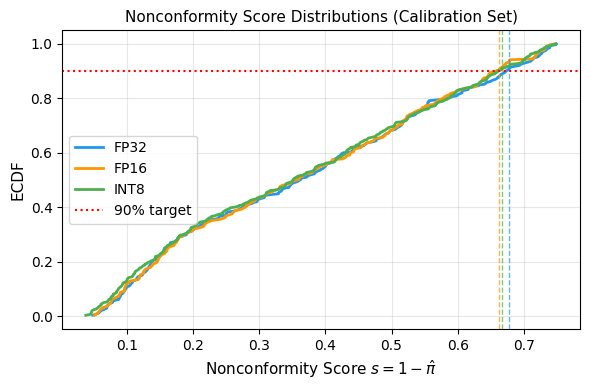

Saved: ecdf_nonconformity.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your calibration data
calib_fp32 = pd.read_csv('results/tables/calib_fp32.csv')
calib_fp16 = pd.read_csv('results/tables/calib_fp16.csv')
calib_int8 = pd.read_csv('results/tables/calib_int8.csv')

# Compute nonconformity scores: s = 1 - confidence
scores = {
    'FP32': 1 - calib_fp32['confidence'].values,
    'FP16': 1 - calib_fp16['confidence'].values,
    'INT8': 1 - calib_int8['confidence'].values,
}

colors = {'FP32': '#2196F3', 'FP16': '#FF9800', 'INT8': '#4CAF50'}

fig, ax = plt.subplots(figsize=(6, 4))

for label, s in scores.items():
    sorted_s = np.sort(s)
    ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
    ax.plot(sorted_s, ecdf, label=label, color=colors[label], linewidth=2)

# Mark the q_hat thresholds
qhats = {'FP32': 0.6771, 'FP16': 0.6628, 'INT8': 0.6670}
for label, q in qhats.items():
    ax.axvline(x=q, color=colors[label], linestyle='--', linewidth=1, alpha=0.7)

ax.axhline(y=0.90, color='red', linestyle=':', linewidth=1.5, label='90% target')
ax.set_xlabel('Nonconformity Score $s = 1 - \hat{\pi}$', fontsize=11)
ax.set_ylabel('ECDF', fontsize=11)
ax.set_title('Nonconformity Score Distributions (Calibration Set)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ecdf_nonconformity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ecdf_nonconformity.png") 